### Extract Resp Features over 3 Second Blocks and Create Feature Matrix

In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path
Libraries loaded successfully


### AIM1 Paths (Rank CM Respiration and H5s)

In [2]:
aim1_resp_path = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs"
aim1_behavior_path = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_boris\baseline csv"

# BLA paths (for side-by-side comparison below)
bla_cm_h5_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_hc\h5_outputs")
bla_cm_boris_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_boris")

aim1_h5_dir = Path(aim1_resp_path)
aim1_boris_dir = Path(aim1_behavior_path)

print(f"Aim1 H5 files   : {len(list(aim1_h5_dir.glob('*.h5')))}")
print(f"Aim1 BORIS files: {len(list(aim1_boris_dir.glob('*.csv')))}")
print(f"BLA H5 files    : {len(list(bla_cm_h5_dir.glob('*.h5')))}")
print(f"BLA BORIS files : {len(list(bla_cm_boris_dir.glob('*.csv')))}")

Aim1 H5 files   : 9
Aim1 BORIS files: 10
BLA H5 files    : 25
BLA BORIS files : 32


### Aim1 vs BLA — key layout differences (inspection notes)

Before merging Aim1 cagemate recordings with BLA cagemate data, the two cohorts differ in **H5 structure**, **loader**, and **filename conventions**. Behavior labels for sniffing are compatible; rank is encoded differently.

| | **Aim1 (ECG cohort1 CM)** | **BLA cagemate** |
|---|---|---|
| **Resp key** | top-level `resp` | `resp_clean/signal` + `resp_clean/time` |
| **Loader to use** | `load_clean_resp_signal()` | `load_clean_resp_signal_cagemate_rank()` |
| **Raw sampling rate** | 20,000 Hz (`resp_metadata`) | ~400 Hz (from time vector) |
| **H5 naming** | `CM_s{mouse}_{rank}{partner}_{date}_{time}_merged.h5` | `{sub}_{par}_{role}_cm_{...}_{date}_{time}.h5` |
| **Rank source** | `d` / `sub` in filename | role letter in H5 + `rank_map` |
| **BORIS naming** | `CM_s{...}_{date}_{time}.1.csv` or `.1_VT.csv` | various tags (`VT_CM`, `VT_SA`, `BORIS_SS`, …) |
| **Sniffing behaviors** | facial / body / anogenital sniffing | same labels |
| **Initiator labels** | `subject`, `social_agent` | same labels |

**Matching caveats (Aim1):**
- 9 H5 files vs 10 BORIS CSVs — some sessions have duplicate BORIS exports or missing pairs.
- `CM_s3_5_d3_6_20250623_160001` H5 is truncated (~355 s); full-length sibling `@170708` has no BORIS.
- `CM_s3_6_sub3_5_20250623_174348.csv` is empty (0 rows).
- `CM_s4_8_sub4_7_20250623.csv` is tab-separated (needs `sep='\t'`); use `...182649.1_VT.csv` instead.

Run the cells below to inspect H5 metadata and a sample BORIS dataframe.

### Inspection of H5 Metadata | Differences between BLA and Aim1

In [3]:
# --- H5 metadata inspection: Aim1 vs BLA ---

def summarize_h5(h5_path, cohort):
    """Collect top-level keys, resp dataset location, and sampling metadata."""
    row = {"cohort": cohort, "file": h5_path.name}
    with h5py.File(h5_path, "r") as f:
        row["top_level_keys"] = ", ".join(f.keys())

        if "resp" in f:
            row["resp_key"] = "resp"
            row["resp_n"] = int(np.asarray(f["resp"].shape).prod())
        elif "resp_clean" in f and "signal" in f["resp_clean"]:
            row["resp_key"] = "resp_clean/signal"
            row["resp_n"] = int(np.asarray(f["resp_clean"]["signal"].shape).prod())
        else:
            row["resp_key"] = np.nan
            row["resp_n"] = np.nan

        meta = {}
        for grp in ["resp_metadata", "metadata", "ekg_metadata"]:
            if grp in f and isinstance(f[grp], h5py.Group):
                meta.update(dict(f[grp].attrs))
        for k in ["sampling_frequency", "duration_sec", "num_samples", "units", "channel"]:
            if k in meta:
                v = meta[k]
                row[k] = float(v) if hasattr(v, "item") else v

        if "resp_clean" in f and "time" in f["resp_clean"]:
            t = np.asarray(f["resp_clean"]["time"][:]).squeeze()
            dt = np.diff(t[np.isfinite(t)])
            if len(dt):
                row["est_fs_from_time"] = round(1.0 / np.median(dt), 1)

    return row


h5_rows = []
for p in sorted(aim1_h5_dir.glob("*.h5")):
    h5_rows.append(summarize_h5(p, "Aim1"))

for p in sorted(bla_cm_h5_dir.glob("*.h5"))[:3]:
    h5_rows.append(summarize_h5(p, "BLA (sample)"))

h5_summary_df = pd.DataFrame(h5_rows)
display(h5_summary_df)

print("\n--- Loader recommendation ---")
print("Aim1  -> load_clean_resp_signal()            (top-level 'resp', 20 kHz -> downsample)")
print("BLA   -> load_clean_resp_signal_cagemate_rank()  (resp_clean/signal, already cleaned)")

,cohort,file,top_level_keys,resp_key,resp_n,sampling_frequency,duration_sec,num_samples,units,channel,est_fs_from_time
0,Aim1,CM_s1_1_d1_2_20250623_111352_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12252312,20000.0,612.61560,12252312.0,volts,analog_ECU_Ain1,NaN
1,Aim1,CM_s1_2_sub1_1_20250623_133932_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12113241,20000.0,605.66205,12113241.0,volts,analog_ECU_Ain1,NaN
2,Aim1,CM_s2_3_d2_4_20250623_151153_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12228653,20000.0,611.43265,12228653.0,volts,analog_ECU_Ain1,NaN
3,Aim1,CM_s2_4_sub2_3_20250623_143348_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12439272,20000.0,621.96360,12439272.0,volts,analog_ECU_Ain1,NaN
4,Aim1,CM_s3_5_d3_6_20250623_160001_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,7108135,20000.0,355.40675,7108135.0,volts,analog_ECU_Ain1,NaN
5,Aim1,CM_s3_5_d3_6_20250623_170708_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12118834,20000.0,605.94170,12118834.0,volts,analog_ECU_Ain1,NaN
6,Aim1,CM_s3_6_sub3_5_20250623_174348_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12085122,20000.0,604.25610,12085122.0,volts,analog_ECU_Ain1,NaN
7,Aim1,CM_s4_7_d4_8_20250623_193718_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12063752,20000.0,603.18760,12063752.0,volts,analog_ECU_Ain1,NaN
8,Aim1,CM_s4_8_sub4_7_20250623_182649_merged.h5,"ekg_metadata, metadata, resp, resp_metadata",resp,12101696,20000.0,605.08480,12101696.0,volts,analog_ECU_Ain1,NaN
9,BLA (sample),1_1_i_cm_1_2_d_20260106_134350.h5,"analog, dio, resp_clean, time",resp_clean/signal,61027,NaN,NaN,NaN,NaN,NaN,100.0



--- Loader recommendation ---
Aim1  -> load_clean_resp_signal()            (top-level 'resp', 20 kHz -> downsample)
BLA   -> load_clean_resp_signal_cagemate_rank()  (resp_clean/signal, already cleaned)


### Aim1 BORIS - raw vs cleaned behavior example | Verifying that both subject and agent initiated data is retained

The raw export uses standard BORIS columns (`Start (s)`, `Stop (s)`, `Subject`, `Behavior`). After `load_clean_boris(subject_only=False)` we keep **both initiators** and **only the three sniffing behaviors** — same filter as BLA.

Below: one well-matched session (`CM_s1_1_d1_2_20250623_111352`) plus a cross-cohort label summary.

In [4]:
# --- BORIS inspection: example session + label comparison ---

EXAMPLE_BORIS = aim1_boris_dir / "CM_s1_1_d1_2_20250623_111352.1.csv"
EXAMPLE_H5   = aim1_h5_dir / "CM_s1_1_d1_2_20250623_111352_merged.h5"

print("Example matched pair:")
print(f"  H5   : {EXAMPLE_H5.name}")
print(f"  BORIS: {EXAMPLE_BORIS.name}\n")

# Raw BORIS (first 10 rows, key columns)
raw_cols = [
    "Subject", "Behavior", "Behavior type", "Start (s)", "Stop (s)", "Duration (s)",
    "Image index start", "Image index stop",
]
raw_boris = pd.read_csv(EXAMPLE_BORIS)
print(f"Raw BORIS: {len(raw_boris)} rows × {len(raw_boris.columns)} cols")
display(raw_boris[raw_cols].head(10))

# Cleaned (pipeline-ready)
clean_boris = load_clean_boris(str(EXAMPLE_BORIS), subject_only=False)
print(f"\nAfter load_clean_boris(subject_only=False): {len(clean_boris)} sniff bouts")
display(clean_boris.head(10))

# --- All Aim1 BORIS files: row counts + initiator breakdown ---
aim1_boris_inventory = []
for csv_path in sorted(aim1_boris_dir.glob("*.csv")):
    try:
        df = pd.read_csv(csv_path)
    except Exception:
        df = pd.read_csv(csv_path, sep="\t")
    n = len(df)
    if n and "Subject" in df.columns:
        initiators = (
            df["Subject"].astype(str).str.lower().str.strip().value_counts().to_dict()
        )
    else:
        initiators = {}
    aim1_boris_inventory.append({
        "file": csv_path.name,
        "n_rows": n,
        "initiators": initiators,
    })

print("\n--- Aim1 BORIS inventory ---")
display(pd.DataFrame(aim1_boris_inventory))

# --- Cross-cohort behavior + initiator labels ---
def boris_label_summary(boris_dir, cohort, max_files=None):
    rows = []
    files = sorted(boris_dir.glob("*.csv"))
    if max_files:
        files = files[:max_files]
    for p in files:
        try:
            df = pd.read_csv(p)
        except Exception:
            df = pd.read_csv(p, sep="\t")
        if df.empty or "Behavior" not in df.columns:
            continue
        df = df.assign(
            Behavior=df["Behavior"].astype(str).str.lower().str.strip(),
            Subject=df["Subject"].astype(str).str.lower().str.strip(),
            cohort=cohort,
            file=p.name,
        )
        rows.append(df[["cohort", "file", "Subject", "Behavior"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

label_df = pd.concat([
    boris_label_summary(aim1_boris_dir, "Aim1"),
    boris_label_summary(bla_cm_boris_dir, "BLA"),
], ignore_index=True)

print("\n--- Initiator labels (both cohorts) ---")
display(label_df.groupby("cohort")["Subject"].value_counts().unstack(fill_value=0))

print("\n--- Behavior labels (both cohorts) ---")
display(label_df.groupby("cohort")["Behavior"].value_counts().head(15))

sniff_behaviors = {"facial sniffing", "body sniffing", "anogenital sniffing"}
for cohort in ["Aim1", "BLA"]:
    sub = label_df[label_df["cohort"] == cohort]
    n_sniff = sub["Behavior"].isin(sniff_behaviors).sum()
    print(f"{cohort}: {n_sniff}/{len(sub)} rows are sniffing behaviors kept by load_clean_boris")

Example matched pair:
  H5   : CM_s1_1_d1_2_20250623_111352_merged.h5
  BORIS: CM_s1_1_d1_2_20250623_111352.1.csv

Raw BORIS: 129 rows × 24 cols


,Subject,Behavior,Behavior type,Start (s),Stop (s),Duration (s),Image index start,Image index stop
0,social_agent,facial sniffing,STATE,9.167,9.567,0.400,275,287.0
1,subject,facial sniffing,STATE,9.233,9.567,0.334,277,287.0
2,social_agent,facial sniffing,STATE,17.867,18.700,0.833,536,561.0
3,subject,facial sniffing,STATE,18.200,18.700,0.500,546,561.0
4,social_agent,facial sniffing,STATE,24.267,24.700,0.433,728,741.0
5,subject,facial sniffing,STATE,24.367,24.733,0.366,731,742.0
6,social_agent,facial sniffing,STATE,25.733,25.900,0.167,772,777.0
7,social_agent,facial sniffing,STATE,28.567,28.733,0.166,857,862.0
8,subject,facial sniffing,STATE,28.600,28.800,0.200,858,864.0
9,social_agent,body sniffing,STATE,30.333,30.733,0.400,910,922.0



After load_clean_boris(subject_only=False): 53 sniff bouts


,Behavior,Initiator,Start,Stop,Duration
0,facial sniffing,social_agent,9.167,9.567,0.400
1,facial sniffing,subject,9.233,9.567,0.334
2,facial sniffing,social_agent,17.867,18.700,0.833
3,facial sniffing,subject,18.200,18.700,0.500
4,facial sniffing,social_agent,24.267,24.700,0.433
5,facial sniffing,subject,24.367,24.733,0.366
6,facial sniffing,social_agent,25.733,25.900,0.167
7,facial sniffing,social_agent,28.567,28.733,0.166
8,facial sniffing,subject,28.600,28.800,0.200
9,body sniffing,social_agent,30.333,30.733,0.400



--- Aim1 BORIS inventory ---


...


--- Initiator labels (both cohorts) ---


Subject,no focal subject,social_agent,subject
cohort,,,
Aim1,7,285,293
BLA,0,1982,1354



--- Behavior labels (both cohorts) ---


cohort  Behavior           
Aim1    facial sniffing         272
        body sniffing           174
        anogenital sniffing      56
        fighting                 34
        chasing                  33
        allogrooming             12
        posturing                 4
BLA     digging                1342
        facial sniffing        1234
        body sniffing           392
        anogenital sniffing     287
        self-grooming            80
        allogrooming              1
Name: count, dtype: int64

Aim1: 502/585 rows are sniffing behaviors kept by load_clean_boris
BLA: 1913/3336 rows are sniffing behaviors kept by load_clean_boris


Rank Map is used to construct feature matrix but will not be available during training

In [83]:
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

### Feature Extraction using Breathmetrics

In [ ]:
# ============================================================
# Main build loop (interaction bouts only):
#   - BLAcm    : cagemate H5 layout (resp_clean/signal)
#   - All bouts padded/cropped to 3 s, dropped if < min_dur or too few breaths
# ============================================================

def _feature_window_bounds(bout_start, bout_stop, feature_window_mode="full", window_sec=2.0):
    """Return (start, stop) for feature extraction inside a BORIS bout."""
    if feature_window_mode == "full":
        return bout_start, bout_stop
    if feature_window_mode == "onset_2s":
        return bout_start, bout_start + window_sec
    if feature_window_mode == "first_2s":
        return bout_start, bout_start + window_sec
    if feature_window_mode == "last_2s":
        return bout_stop - window_sec, bout_stop
    raise ValueError(f"Unknown feature_window_mode: {feature_window_mode}")


def add_engineered_features(df):
    """Ratio features + per-subject / per-trial z-scores for all numeric resp columns."""
    df = df.copy()
    if {"mean_inhale_vol", "mean_exhale_vol"}.issubset(df.columns):
        df["vol_asymmetry"] = df["mean_inhale_vol"] / (df["mean_exhale_vol"].abs() + 1e-8)
    if {"mean_peak_insp_flow", "mean_peak_exp_flow"}.issubset(df.columns):
        df["peak_flow_ratio"] = df["mean_peak_insp_flow"] / (df["mean_peak_exp_flow"].abs() + 1e-8)

    meta = {
        "Behavior", "Initiator", "Start", "Stop", "Duration", "PreBoutRespRate", "Trial", "Subject",
        "Condition", "Rank", "Type", "Label", "h5_path", "FeatureWindow",
    }
    numeric_cols = [
        c for c in df.columns
        if c not in meta and pd.api.types.is_numeric_dtype(df[c])
        and not c.endswith("_z_subject") and not c.endswith("_z_trial")
    ]
    for col in numeric_cols:
        df[f"{col}_z_subject"] = df.groupby("Subject")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
        df[f"{col}_z_trial"] = df.groupby("Trial")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
    return df


def build_feature_matrix_5s(
    resp_paths_interactions, boris_paths_valence,
    rank_map,
    target_dur=3.0, min_dur=1.0,
    pre_bout_window=2.0,
    feature_window_mode="full",
    feature_window_sec=2.0,
    data_type="rodentAirflow",
    target_srate=100,
    min_breaths_per_bout=2,
    subject_only=False,
):
    all_rows = []

    for trial, h5_path in resp_paths_interactions.items():
        print(f"\n[Interaction] {trial}")

        if trial.startswith("BLA"):
            signal, time, fs, meta = load_clean_resp_signal_cagemate_rank(
                h5_path, target_rate=target_srate
            )
        else:
            signal, time, fs, meta = load_clean_resp_signal(
                h5_path, target_rate=target_srate
            )
        if signal is None:
            print("  ❌ Load failed"); continue

        # Signal Checks
        print("signal len:", len(signal))
        print("fs:", fs)
        print("nan count:", np.isnan(signal).sum())
        print("inf count:", np.isinf(signal).sum())
        print("min/max:", np.nanmin(signal), np.nanmax(signal))
        print("std:", np.nanstd(signal))
        print("first 10:", signal[:10])

        bm = fit_bm_session(signal, fs, data_type=data_type)
        if bm is None: continue
        print(f"  ✓ {len(bm.inhaleOnsets)} breaths detected")

        subj      = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank      = rank_map.get(subj, np.nan)

        if trial not in boris_paths_valence:
            print(f"  ⚠️  No BORIS for {trial}, skipping"); continue

        boris_df = load_clean_boris(boris_paths_valence[trial], subject_only=subject_only)
        if boris_df.empty:
            print(f"  ⚠️  Empty BORIS, skipping"); continue

        boris_df = standardize_bouts_to_target(boris_df, time[0], time[-1],
                                        target_dur=target_dur, min_dur=min_dur)
        n_dropped_dur = 0
        for _, bout in boris_df.iterrows():
            feat_start, feat_stop = _feature_window_bounds(
                bout["Start"], bout["Stop"],
                feature_window_mode=feature_window_mode,
                window_sec=feature_window_sec,
            )
            feats = extract_bout_features(bm, feat_start, feat_stop)
            if feats is None or feats["n_breaths"] < min_breaths_per_bout:
                n_dropped_dur += 1; continue

            pre_start = max(time[0], bout["Start"] - pre_bout_window)
            pre_feats = extract_bout_features(bm, pre_start, bout["Start"])
            pre_rate  = pre_feats["breathing_rate_hz"] if pre_feats else np.nan

            row = {
                "Behavior"        : bout.get("Behavior", np.nan),
                "Initiator"       : bout.get("Initiator", np.nan),
                "Start"           : bout["Start"],
                "Stop"            : bout["Stop"],
                "Duration"        : bout["Duration"],
                "PreBoutRespRate"  : pre_rate,
                "Trial"           : trial,
                "Subject"         : subj,
                "Condition"       : condition,
                "Rank"            : rank,
                "Type"            : "Interaction",
                "Label"           : np.nan,
                "h5_path"         : h5_path,
                "FeatureWindow"   : feature_window_mode,
            }
            row.update(feats)
            row["resp_rate_delta"] = (
                row["breathing_rate_hz"] - pre_rate
                if not np.isnan(pre_rate) else np.nan
            )
            all_rows.append(row)

        if n_dropped_dur:
            print(f"  → Dropped {n_dropped_dur} bouts (too few breaths after padding)")

    # ── Assemble ───────────────────────────────────────────────
    if not all_rows:
        print("\n⚠️  No rows collected."); return pd.DataFrame()

    master_df = pd.DataFrame(all_rows).reset_index(drop=True)

    master_df["breathing_rate_z"] = (
        master_df.groupby("Trial")["breathing_rate_hz"]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan)
    )

    print(f"\n✅ Feature matrix: {len(master_df)} rows × {len(master_df.columns)} cols")
    print(f"   Trials    : {master_df['Trial'].nunique()}")
    print(f"   Subjects  : {master_df['Subject'].nunique()}")
    print(f"   Type dist :\n{master_df['Type'].value_counts()}")
    if "Initiator" in master_df.columns:
        print(f"   Initiator dist :\n{master_df['Initiator'].value_counts()}")

    return master_df

### BLA CM Mice - Rank Dynamics are found through the H5 Filenames

In [89]:
# --- Add cagemate BLA mice (cm) ---

bla_cm_h5_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_hc\h5_outputs")
bla_cm_boris_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_boris")

# h5 filename pattern examples:
#   1_1_i_cm_1_2_d_20260106_134350.h5
#   2_1_d_cm_2.3_i_20260106_105109.h5
#   2_2_s_cm_2_1_d_20260108_120453.rec.h5
h5_pat = re.compile(
    r"^(?P<subA>\d+)_(?P<subB>\d+)_(?P<subRole>[dis])_cm_(?P<parA>\d+)[._](?P<parB>\d+)_(?P<parRole>[dis])_(?P<date>\d{8})_(?P<time>\d{6})(?:\.rec)?\.h5$",
    re.IGNORECASE,
)

session_to_h5 = {}  # (subject_id, cagemate_id, date, time) -> h5 path
bla_rank_map = {}   # subject_id -> Dominant/Subordinate (no entry for 'i')

for h5_path in sorted(bla_cm_h5_dir.glob("*.h5")):
    m = h5_pat.match(h5_path.name)
    if not m:
        continue

    sub_id = f"{m.group('subA')}_{m.group('subB')}"
    # Normalize par_id: some H5 names use a dot (e.g. 2.3) where BORIS uses underscore.
    par_id = f"{m.group('parA')}_{m.group('parB').replace('.', '_')}"
    date = m.group('date')
    time = m.group('time')

    key = (sub_id, par_id, date, time)

    # Prefer the non-.rec file when both exist.
    if key not in session_to_h5:
        session_to_h5[key] = str(h5_path.resolve())
    else:
        existing = session_to_h5[key]
        if (
            ".rec.h5" in os.path.basename(existing).lower()
            and ".rec.h5" not in h5_path.name.lower()
        ):
            session_to_h5[key] = str(h5_path.resolve())

    # Encode hierarchy for the recorded mouse.
    role = m.group('subRole').lower()
    if role == "d":
        bla_rank_map[sub_id] = "Dominant"
    elif role == "s":
        bla_rank_map[sub_id] = "Subordinate"

# BORIS filename patterns (naming varies). We parse Dominant/Subordinate from the role letter.
# Examples:
#   1_1_2_i_cm_1_2_d_20260106_134350.1_BORIS_SS.csv
#   4_3_2_d_cm_4_1_s_20260107_113120.1_boris_AJ_with_image_indices_with_image_indices.csv
# One BORIS variant lacks the literal token "_cm_".
boris_pat_cm = re.compile(
    r"^(?P<subA>\d+)_(?P<subB>\d+)(?:_\d+)?_(?P<subRole>[dis])_cm_(?P<parA>\d+)_(?P<parB>\d+)_(?P<parRole>[dis])_(?P<date>\d{8})_(?P<time>\d{6})(?:\.\d+)?_(?P<tag>.+)$",
    re.IGNORECASE,
)

boris_pat_nocm = re.compile(
    r"^(?P<subA>\d+)_(?P<subB>\d+)(?:_\d+)?_(?P<subRole>[dis])_(?P<parA>\d+)_(?P<parB>\d+)_(?P<parRole>[dis])_(?P<date>\d{8})_(?P<time>\d{6})(?:\.\d+)?_(?P<tag>.+)$",
    re.IGNORECASE,
)

resp_paths_cm_bla = {}   # trial_key -> h5
boris_paths_cm_bla = {}  # trial_key -> boris csv

for csv_path in sorted(bla_cm_boris_dir.glob("*.csv")):
    base = csv_path.stem  # without .csv

    m = boris_pat_cm.match(base) or boris_pat_nocm.match(base)
    if not m:
        print(f"  ⚠️ Could not parse BLA BORIS filename: {csv_path.name}")
        continue

    sub_id = f"{m.group('subA')}_{m.group('subB')}"
    par_id = f"{m.group('parA')}_{m.group('parB')}"
    date = m.group('date')
    time = m.group('time')
    tag = m.group('tag')

    session_key = (sub_id, par_id, date, time)
    if session_key not in session_to_h5:
        print(
            f"  ⚠️ No matching BLA .h5 for BORIS {csv_path.name} "
            f"(key={session_key})"
        )
        continue

    tag_clean = re.sub(r"[^A-Za-z0-9]+", "_", tag).strip("_")
    trial_key = f"BLAcm_{sub_id}_{par_id}_{date}_{time}_{tag_clean}"

    resp_paths_cm_bla[trial_key] = session_to_h5[session_key]
    boris_paths_cm_bla[trial_key] = str(csv_path.resolve())

# Merge BLA into the existing interaction inputs.
for subj_id, rnk in bla_rank_map.items():
    if subj_id in rank_map and rank_map[subj_id] != rnk:
        print(f"  ⚠️ Rank conflict for {subj_id}: {rank_map[subj_id]} vs {rnk}; using {rnk}")
    rank_map[subj_id] = rnk

resp_paths_interactions = {**resp_paths_interactions, **resp_paths_cm_bla}
boris_paths_valence = {**boris_paths_valence, **boris_paths_cm_bla}

print(f"\nBLA cm trials added: {len(resp_paths_cm_bla)} (resp) / {len(boris_paths_cm_bla)} (boris)")
print(f"Total interaction trials now: {len(resp_paths_interactions)}")

# --- Build feature matrix (3s windows) ---
master_df_5s = build_feature_matrix_5s(
    resp_paths_interactions = resp_paths_interactions,
    boris_paths_valence     = boris_paths_valence,
    rank_map                = rank_map,
    target_dur              = 3.0,
    min_dur                 = 0.5,
    pre_bout_window         = 2.0,
    data_type               = "rodentAirflow",
    target_srate            = 400,
    min_breaths_per_bout    = 2,
)

# Interactions only (no BLRI baseline pseudo-bouts)
master_df_5s = master_df_5s[master_df_5s["Type"] == "Interaction"].reset_index(drop=True)
master_df_5s = add_engineered_features(master_df_5s)

# Optional: 2 s windows anchored at interaction onset (re-run only when experimenting)
RUN_ONSET_2S_EXTRACTION = True
if RUN_ONSET_2S_EXTRACTION:
    master_df_onset2s = build_feature_matrix_5s(
        resp_paths_interactions=resp_paths_interactions,
        boris_paths_valence=boris_paths_valence,
        rank_map=rank_map,
        target_dur=3.0,
        min_dur=0.5,
        pre_bout_window=2.0,
        feature_window_mode="onset_2s",
        feature_window_sec=2.0,
        data_type="rodentAirflow",
        target_srate=400,
        min_breaths_per_bout=2,
    )
    master_df_onset2s = master_df_onset2s[master_df_onset2s["Type"] == "Interaction"].reset_index(drop=True)
    master_df_onset2s = add_engineered_features(master_df_onset2s)
    print(f"Onset-2s matrix: {len(master_df_onset2s)} rows")

  ⚠️ No matching BLA .h5 for BORIS 1_3_2_s_1_2_d_20260107_165340.1_boris_AJ_with_image_indices_with_image_indices.csv (key=('1_3', '1_2', '20260107', '165340'))

BLA cm trials added: 30 (resp) / 30 (boris)
Total interaction trials now: 46

[Interaction] RI1_3_6
original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
signal len: 241309
fs: 400
nan count: 0
inf count: 0
min/max: -3156.867102862241 10588.634104905961
std: 858.8590672038537
first 10: [-467.88675514 -496.19362445 -525.68070149 -556.31412296 -587.02853624
 -616.16974673 -641.92086911 -662.60366276 -676.86850375 -683.78037763]
  ✓ 3902 breaths detected

[Interaction] RI2_3_6
original resp len: 12200094
original fs: 20000.0
duration_sec: 610.0047
expected duration from len/fs: 610.0047
signal len: 244002
fs: 400
nan count: 0
inf count: 0
min/max: -3807.9919642752016 12918.181040034846
std: 664.2060884060568
first 10: [-223.21616649 -206.90451895 -189.94693921 -171.5405813

In [90]:
# Confirm all windows are ~3 s interaction bouts
print(master_df_5s["Duration"].describe())
print("\nInteraction windows:", len(master_df_5s))
print("Trials:", master_df_5s["Trial"].nunique())
print("Subjects:", master_df_5s["Subject"].nunique())
print("Behavior counts:\n", master_df_5s["Behavior"].value_counts())
print("Feature cols:", [c for c in master_df_5s.columns if c not in
    ["BoutID","Behavior","Initiator","Start","Stop","Duration","Label",
     "PreBoutRespRate","Trial","Subject","Condition","Rank",
     "Type","resp_rate_delta","breathing_rate_z"]])

count    8.950000e+02
mean     3.000000e+00
std      2.142943e-15
min      3.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      3.000000e+00
max      3.000000e+00
Name: Duration, dtype: float64

Interaction windows: 895
Trials: 36
Subjects: 22
Behavior counts:
 Behavior
facial sniffing        526
body sniffing          232
anogenital sniffing    137
Name: count, dtype: int64
Feature cols: ['h5_path', 'FeatureWindow', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'ex

In [91]:
master_df_5s.head()

,Behavior,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,Condition,Rank,Type,Label,h5_path,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,10.9830,13.9830,3.0,6.869221,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,31,10.647737,0.093917,0.141639,0.044032,0.349303,0.047742,0.297815,0.922297,1443.020432,-1261.673197,0.306335,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,1.017509,0.502284,-0.749391,-0.282025,2.050012,2.622195,1.459815,1.427727,0.042198,-0.089186,-0.939111,-1.126521
1,anogenital sniffing,14.0865,17.0865,3.0,9.921671,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,30,9.822185,0.101810,0.302527,0.044833,0.387117,0.051417,0.522124,0.871961,1326.573540,-996.957219,0.364073,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,0.311143,-0.150065,-0.838256,-0.416208,-0.168601,0.005932,0.736164,0.719983,0.544838,0.352431,-0.097675,0.408408
2,anogenital sniffing,24.7930,27.7930,3.0,9.656925,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,28,9.375000,0.106667,0.263935,0.047321,0.455980,0.053929,0.271564,0.877483,1270.002939,-997.226511,0.295554,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,0.392415,-0.075008,-0.823362,-0.393719,-0.272974,-0.117149,0.344178,0.336612,-0.031439,-0.153884,-0.354704,-0.060458
3,body sniffing,26.6205,29.6205,3.0,9.781210,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,27,9.203540,0.108654,0.272187,0.046296,0.473362,0.056574,0.338927,0.818331,1115.364123,-978.871961,0.259686,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,-0.042787,-0.476929,-0.419099,0.216701,-0.442171,-0.316671,0.193882,0.189620,-1.006413,-1.010491,-0.958459,-1.161815
4,anogenital sniffing,27.8615,30.8615,3.0,9.411765,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,28,9.574468,0.104444,0.174846,0.043393,0.137906,0.056250,0.317952,0.771429,1188.448729,-989.114420,0.269907,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,-0.306317,-0.720307,0.059602,0.939521,-0.018602,0.182816,0.519024,0.507616,-0.776013,-0.808063,-0.678907,-0.651862


In [92]:
nan_counts = master_df_5s.isna().sum()
nan_pct = master_df_5s.isna().mean() * 100

nan_summary = pd.DataFrame({
    "nan_count": nan_counts,
    "nan_percent": nan_pct
}).sort_values(by="nan_percent", ascending=False)

nan_summary

,nan_count,nan_percent
Label,895,100.000000
cv_inhale_pause_dur_z_trial,883,98.659218
cv_inhale_pause_dur_z_subject,880,98.324022
cv_inhale_pause_dur,879,98.212291
cv_exhale_pause_dur_z_trial,780,87.150838
...,...,...
Stop,0,0.000000
Trial,0,0.000000
Subject,0,0.000000
peak_flow_ratio,0,0.000000


## Breathmetrics Respiration Features
- n_breaths: Total number of detected breaths (typically counted via inhale onsets).

- breathing_rate_hz: Number of breaths per second, computed from the average time between consecutive inhales.

- mean_ibi_sec: Average inter-breath interval (time between breaths), equal to the inverse of breathing rate.

- cv_breathing_rate: Coefficient of variation of breath timing, measuring variability in inter-breath intervals.

- mean_inhale_dur_sec: Average duration of inhalation phases across breaths.

- cv_inhale_dur: Variability (coefficient of variation) of inhale durations.

- mean_exhale_dur_sec: Average duration of exhalation phases across breaths.

- cv_exhale_dur: Variability (coefficient of variation) of exhale durations.

- ie_ratio: Ratio of inhale duration to exhale duration, reflecting breathing asymmetry.

- mean_peak_insp_flow: Average maximum airflow achieved during inhalation (peak inspiratory flow).

- mean_peak_exp_flow: Average maximum airflow during exhalation (peak expiratory flow, typically trough values).

- cv_peak_insp_flow: Variability of peak inspiratory flow across breaths.

- mean_inhale_vol: Average volume of air inhaled per breath (integral of airflow during inhale).

- mean_exhale_vol: Average volume of air exhaled per breath.

- mean_tidal_vol: Average total air displaced per breath (inhale + exhale volume).

- cv_tidal_vol: Variability of tidal volume across breaths.

- minute_ventilation: Total air volume per second (or minute if scaled), computed as breathing rate × tidal volume.

- pct_breaths_with_inhale_pause: Proportion of breaths that include a pause after inhalation.

- mean_inhale_pause_dur_sec: Average duration of pauses occurring after inhalation.

- cv_inhale_pause_dur: Variability of inhale pause durations.

- inhale_pause_duty_cycle: Fraction of each breathing cycle spent in inhale pause.

- pct_breaths_with_exhale_pause: Proportion of breaths that include a pause after exhalation.

- mean_exhale_pause_dur_sec: Average duration of pauses occurring after exhalation.

- cv_exhale_pause_dur: Variability of exhale pause durations.

- exhale_pause_duty_cycle: Fraction of each breathing cycle spent in exhale pause.

- inhale_duty_cycle: Fraction of each breathing cycle spent inhaling.

- exhale_duty_cycle: Fraction of each breathing cycle spent exhaling.

### Dropping bad recording | no behavior

In [93]:
# RI1_3_5
master_df_5s = master_df_5s[master_df_5s["Trial"] != "RI1_3_5"]

# Drop any windows where we couldn't determine a rank label.
# (e.g., cagemate BLA recordings with role 'i' or any unexpected filename.)
master_df_5s = master_df_5s[master_df_5s["Rank"].notna()].copy()

master_df_5s["Trial"].unique()

array(['RI1_3_6', 'RI2_3_6', 'RI1_4_7', 'RI2_4_7', 'RI1_2_3', 'RI2_2_3',
       'RI1_4_8', 'RI1_1_1', 'RI2_1_1', 'RI1_1_2', 'RI2_1_2', 'RI1_2_4',
       'RI2_2_4', 'RI2_3_5', 'BLAcm_1_1_1_2_20260106_134350_BORIS_SS',
       'BLAcm_1_1_1_3_20260107_163611_VT_CM',
       'BLAcm_1_2_1_3_20260108_114416_VT_CM',
       'BLAcm_2_1_2_2_20260108_112426_VT_CM',
       'BLAcm_2_1_2_3_20260106_105109_BORIS_SS',
       'BLAcm_2_2_2_1_20260108_120453_VT_CM',
       'BLAcm_2_2_2_3_20260106_132549_boris_AJ_with_image_indices',
       'BLAcm_3_2_3_3_20260107_140924_boris_AJ_with_image_indices',
       'BLAcm_3_3_3_1_20260106_124546_boris_AJ_with_image_indices',
       'BLAcm_3_3_3_2_20260107_171330_VT_CM',
       'BLAcm_4_1_4_2_20260107_160439_VT_CM',
       'BLAcm_4_2_4_1_20260107_150836_VT_CM',
       'BLAcm_4_3_4_1_20260107_113120_boris_AJ_with_image_indices',
       'BLAcm_6_2_6_3_20260107_154939_boris_AJ_with_image_indices',
       'BLAcm_7_1_7_2_20260106_111330_BORIS',
       'BLAcm_7_2_7_1_2026

In [94]:
master_df_5s.head()

,Behavior,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,Condition,Rank,Type,Label,h5_path,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,10.9830,13.9830,3.0,6.869221,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,31,10.647737,0.093917,0.141639,0.044032,0.349303,0.047742,0.297815,0.922297,1443.020432,-1261.673197,0.306335,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,1.017509,0.502284,-0.749391,-0.282025,2.050012,2.622195,1.459815,1.427727,0.042198,-0.089186,-0.939111,-1.126521
1,anogenital sniffing,14.0865,17.0865,3.0,9.921671,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,30,9.822185,0.101810,0.302527,0.044833,0.387117,0.051417,0.522124,0.871961,1326.573540,-996.957219,0.364073,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,0.311143,-0.150065,-0.838256,-0.416208,-0.168601,0.005932,0.736164,0.719983,0.544838,0.352431,-0.097675,0.408408
2,anogenital sniffing,24.7930,27.7930,3.0,9.656925,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,28,9.375000,0.106667,0.263935,0.047321,0.455980,0.053929,0.271564,0.877483,1270.002939,-997.226511,0.295554,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,0.392415,-0.075008,-0.823362,-0.393719,-0.272974,-0.117149,0.344178,0.336612,-0.031439,-0.153884,-0.354704,-0.060458
3,body sniffing,26.6205,29.6205,3.0,9.781210,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,27,9.203540,0.108654,0.272187,0.046296,0.473362,0.056574,0.338927,0.818331,1115.364123,-978.871961,0.259686,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,-0.042787,-0.476929,-0.419099,0.216701,-0.442171,-0.316671,0.193882,0.189620,-1.006413,-1.010491,-0.958459,-1.161815
4,anogenital sniffing,27.8615,30.8615,3.0,9.411765,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,28,9.574468,0.104444,0.174846,0.043393,0.137906,0.056250,0.317952,0.771429,1188.448729,-989.114420,0.269907,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,-0.306317,-0.720307,0.059602,0.939521,-0.018602,0.182816,0.519024,0.507616,-0.776013,-0.808063,-0.678907,-0.651862


Pickling

In [95]:
DATA_DIR = Path(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# master_df_5s.to_pickle(DATA_DIR / "Raw-Breathmatrics-Features")
master_df_5s.to_pickle(DATA_DIR / "Raw-Breathmatrics-Features-Rank")
pd.to_pickle(resp_paths_interactions, DATA_DIR / "resp_paths_interactions_rank.pkl")

if RUN_ONSET_2S_EXTRACTION:
    master_df_onset2s.to_pickle(DATA_DIR / "Raw-Breathmatrics-Features-Rank-onset2s")

print("Saved:", DATA_DIR / "Raw-Breathmatrics-Features-Rank")

Saved: C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\Raw-Breathmatrics-Features-Rank


### Visual spot-checks (raw respiration + BM onsets)
Pick a few dominant vs subordinate bouts and inspect whether breath detection looks reliable during active sniffing.

original resp len: 12089585
original fs: 20000.0
duration_sec: 604.4791
expected duration from len/fs: 604.47925


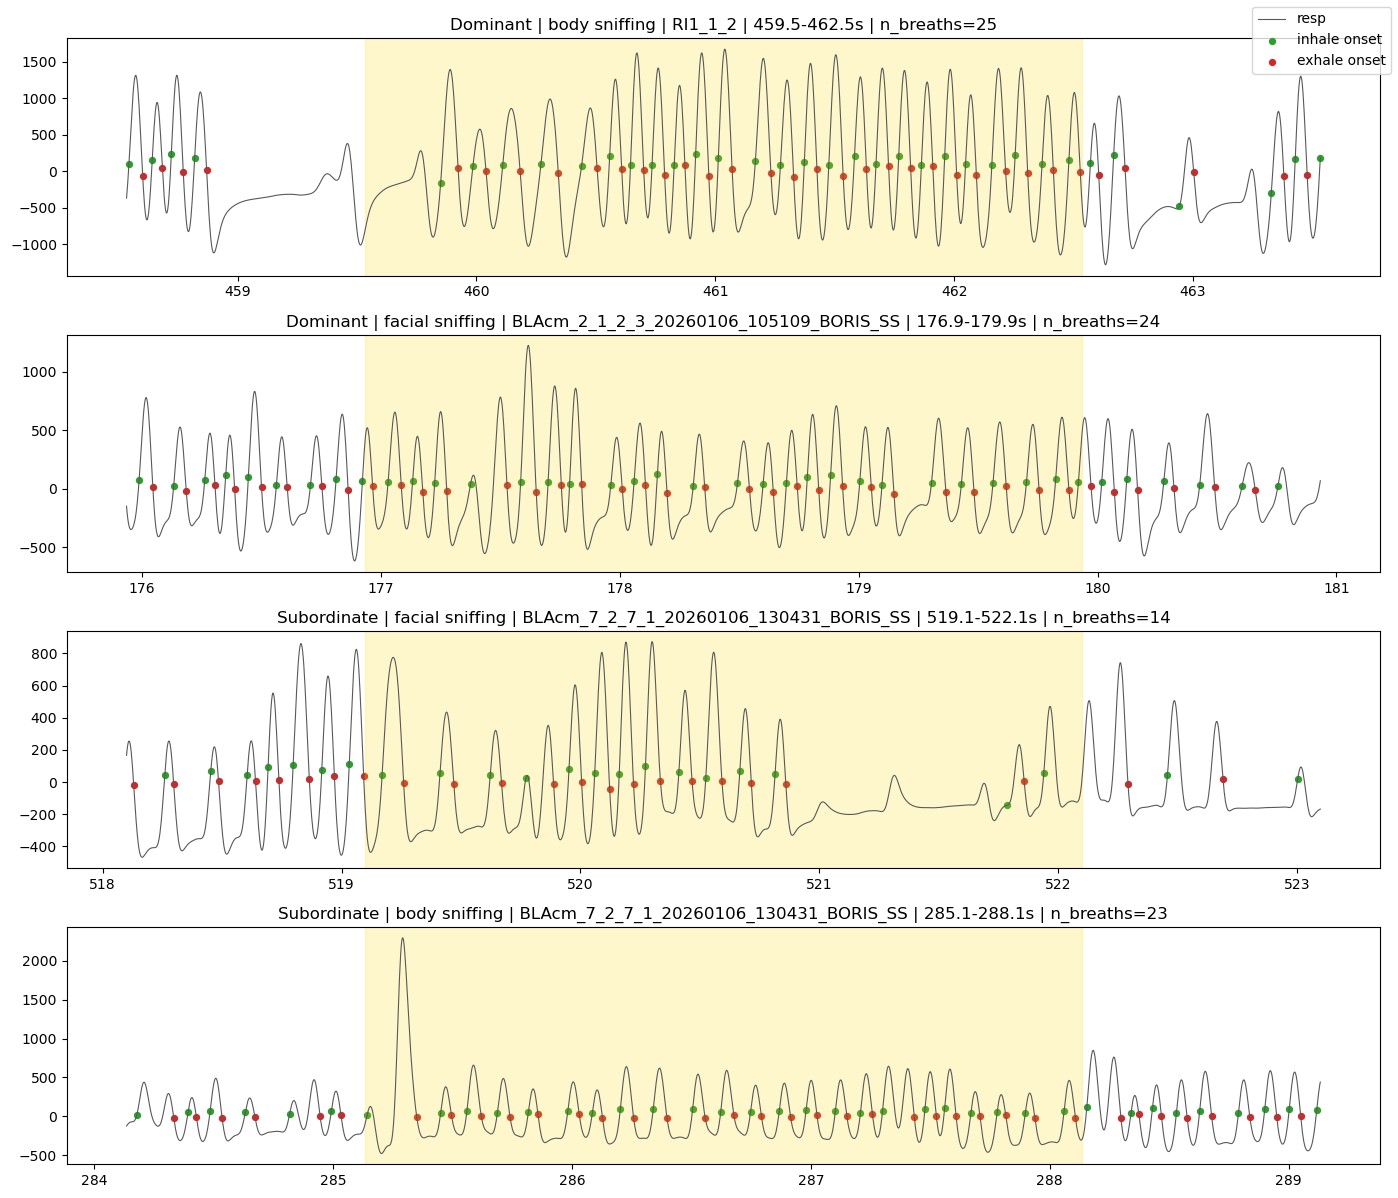

In [96]:
def plot_bout_respiration_spotcheck(df, resp_paths, n_per_rank=2, pad_sec=1.0, random_state=42):
    """Plot raw respiration with BreathMetrics inhale/exhale onsets for sampled bouts."""
    rng = np.random.default_rng(random_state)
    fig, axes = plt.subplots(n_per_rank * 2, 1, figsize=(14, 3 * n_per_rank * 2), sharex=False)
    if len(axes.shape) == 0:
        axes = np.array([axes])

    ax_idx = 0
    for rank in ["Dominant", "Subordinate"]:
        subset = df[(df["Rank"] == rank) & df["h5_path"].notna()] if "h5_path" in df.columns else df[df["Rank"] == rank]
        if subset.empty:
            continue
        picks = subset.sample(n=min(n_per_rank, len(subset)), random_state=rng.integers(1e9)).iterrows()
        for _, row in picks:
            trial = row["Trial"]
            h5_path = row["h5_path"] if "h5_path" in row.index and pd.notna(row["h5_path"]) else resp_paths.get(trial)
            if not h5_path:
                continue
            if str(trial).startswith("BLA"):
                signal, time, fs, _ = load_clean_resp_signal_cagemate_rank(h5_path, target_rate=400)
            else:
                signal, time, fs, _ = load_clean_resp_signal(h5_path, target_rate=400)
            if signal is None:
                continue
            bm = fit_bm_session(signal, fs, data_type="rodentAirflow")
            if bm is None:
                continue

            t0 = max(time[0], row["Start"] - pad_sec)
            t1 = min(time[-1], row["Stop"] + pad_sec)
            mask = (time >= t0) & (time <= t1)
            ax = axes[ax_idx]
            ax.plot(time[mask], signal[mask], color="0.35", lw=0.8, label="resp")

            inhale_t = np.asarray(bm.inhaleOnsets, dtype=float) / fs
            exhale_t = np.asarray(bm.exhaleOnsets, dtype=float) / fs
            inhale_t = inhale_t[(inhale_t >= t0) & (inhale_t <= t1)]
            exhale_t = exhale_t[(exhale_t >= t0) & (exhale_t <= t1)]
            ax.scatter(inhale_t, np.interp(inhale_t, time[mask], signal[mask]), s=18, c="tab:green", label="inhale onset")
            ax.scatter(exhale_t, np.interp(exhale_t, time[mask], signal[mask]), s=18, c="tab:red", label="exhale onset")
            ax.axvspan(row["Start"], row["Stop"], color="gold", alpha=0.2)
            ax.set_title(
                f"{rank} | {row.get('Behavior', '?')} | {trial} | "
                f"{row['Start']:.1f}-{row['Stop']:.1f}s | n_breaths={row.get('n_breaths', '?')}"
            )
            ax_idx += 1

    for j in range(ax_idx, len(axes)):
        axes[j].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()


plot_bout_respiration_spotcheck(master_df_5s, resp_paths_interactions, n_per_rank=2)

### Quick Overview of Behavior by Recording

In [97]:
import pandas as pd

summary = []

for key, path in boris_paths_valence.items():
    try:
        df = pd.read_csv(path)
        cols = set(df.columns)

        summary.append({
            "session": key,
            "has_image_start": "Image index start" in cols,
            "has_image_stop": "Image index stop" in cols,
            "has_start_sec": "Start (s)" in cols,
            "has_stop_sec": "Stop (s)" in cols,
            "n_rows": len(df)
        })

    except Exception as e:
        summary.append({
            "session": key,
            "error": str(e)
        })

summary_df = pd.DataFrame(summary)
summary_df


,session,has_image_start,has_image_stop,has_start_sec,has_stop_sec,n_rows
0,RI1_3_6,True,True,True,True,37
1,RI2_3_6,True,True,True,True,109
2,RI1_4_7,True,True,True,True,37
3,RI2_4_7,True,True,True,True,108
4,RI1_2_3,True,True,True,True,44
5,RI2_2_3,True,True,True,True,102
6,RI1_4_8,True,True,True,True,55
7,RI2_4_8,True,True,True,True,113
8,RI1_1_1,False,False,True,True,92
9,RI2_1_1,False,False,True,True,37


### OG Feature Matrix no new features

#### Resp Features Present
- BoutRespRate
- PreBoutRespRate
- SessionRate
- BoutRespRate_pre_delta
- BoutRespRate_z

In [98]:
print("\n==============================")
print("Processing Valence (RI1/RI2)")
print("==============================")

try:
    master_df_valence = process_all_trials_bout_level(resp_paths_valence, boris_paths_valence, rank_map)
    print(f"✓ Valence processing complete: {len(master_df_valence)} rows")
except Exception as e:
    print(f"✗ Error processing valence data: {e}")
    print("Attempting to continue with available data...")
    master_df_valence = pd.DataFrame()


Processing Valence (RI1/RI2)
Processing RI1_3_6...
original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
   → Filtered 4 short bouts
Processing RI2_3_6...
original resp len: 12200094
original fs: 20000.0
duration_sec: 610.0047
expected duration from len/fs: 610.0047
   → Filtered 12 short bouts
Processing RI1_4_7...
original resp len: 12583112
original fs: 20000.0
duration_sec: 629.1556
expected duration from len/fs: 629.1556
   → Filtered 3 short bouts
Processing RI2_4_7...
original resp len: 12129332
original fs: 20000.0
duration_sec: 606.4666
expected duration from len/fs: 606.4666
   → Filtered 1 short bouts
Processing RI1_2_3...
original resp len: 12058916
original fs: 20000.0
duration_sec: 602.9458
expected duration from len/fs: 602.9458
   → Filtered 18 short bouts
Processing RI2_2_3...
original resp len: 12184065
original fs: 20000.0
duration_sec: 609.20325
expected duration from len/fs: 609.20325
   → Filtered 3 short 

In [99]:
master_df_valence.columns

Index(['Behavior', 'Subject', 'Start', 'Stop', 'Duration', 'BoutRespRate', 'PreBoutRespRate', 'BoutID', 'Trial', 'Condition', 'Rank', 'SessionRate', 'Type', 'BoutRespRate_pre_delta', 'BoutRespRate_z'], dtype='object')

In [100]:
master_df_valence.head()

,Behavior,Subject,Start,Stop,Duration,BoutRespRate,PreBoutRespRate,BoutID,Trial,Condition,Rank,SessionRate,Type,BoutRespRate_pre_delta,BoutRespRate_z
0,facial sniffing,3_6,11.966,13.000,1.034,8.814815,9.167834,0,RI1_3_6,RI1,Dominant,8.07892,Interaction,-0.353019,-0.555753
1,anogenital sniffing,3_6,14.483,16.690,2.207,9.704521,9.766671,1,RI1_3_6,RI1,Dominant,8.07892,Interaction,-0.062151,0.729896
2,anogenital sniffing,3_6,25.034,27.552,2.518,9.152463,9.388105,2,RI1_3_6,RI1,Dominant,8.07892,Interaction,-0.235642,-0.067842
3,body sniffing,3_6,27.793,28.448,0.655,10.040404,9.167320,3,RI1_3_6,RI1,Dominant,8.07892,Interaction,0.873084,1.215257
4,anogenital sniffing,3_6,28.862,29.861,0.999,9.180884,8.654543,4,RI1_3_6,RI1,Dominant,8.07892,Interaction,0.526342,-0.026772


In [101]:
master_df_valence["Condition"].value_counts()

Condition
RI1     273
RI2      37
BLRI      7
Name: count, dtype: int64

#### Drop rows with Duration < 5 | Not doing that rn

In [102]:
len(master_df_valence)

317

In [103]:
# master_df_valence = master_df_valence[master_df_valence["Duration"] >= 5]
# print(f"After filtering Duration >= 5: {len(master_df_valence)} rows")

### Behavioral summary (interaction bouts only)

In [104]:
def assign_cohort(df):
    """Map Condition/Trial to cohort label for summary tables."""
    out = []
    for _, row in df.iterrows():
        c, t = str(row["Condition"]), str(row["Trial"])
        if c.startswith("BLA") or t.startswith("BLA"):
            out.append("BLA_cm")
        elif c in ("RI1", "RI2"):
            out.append("ECG_cohort1_valence")
        else:
            out.append(c)
    return pd.Series(out, index=df.index)


def summarize_behaviors(df, boris_paths=None):
    """Print behavior/cohort coverage for the interaction feature matrix."""
    inter = df[df["Type"] == "Interaction"].copy()
    inter["Cohort"] = assign_cohort(inter)

    print("=" * 70)
    print("INTERACTION FEATURE MATRIX SUMMARY")
    print("=" * 70)
    print(f"Rows: {len(inter)} | Trials: {inter['Trial'].nunique()} | Subjects: {inter['Subject'].nunique()}")
    print()

    print("--- Behavior counts ---")
    beh_counts = inter["Behavior"].value_counts()
    print(beh_counts.to_string())
    print("\nPercent of interaction windows:")
    for beh, pct in (beh_counts / len(inter) * 100).round(1).items():
        print(f"  {beh}: {pct}%")
    print()

    print("--- Cohort distribution ---")
    print(inter["Cohort"].value_counts().to_string())
    print()

    print("--- Behavior x Cohort ---")
    print(pd.crosstab(inter["Behavior"], inter["Cohort"], margins=True).to_string())
    print()

    print("--- Behavior x Rank ---")
    print(pd.crosstab(inter["Behavior"], inter["Rank"], margins=True).to_string())
    print()

    print("--- Trials per cohort ---")
    for cohort in sorted(inter["Cohort"].unique()):
        sub = inter[inter["Cohort"] == cohort]
        trials = sorted(sub["Trial"].unique())
        print(f"\n{cohort}: {len(trials)} trials, {len(sub)} windows")
        for trial in trials:
            tsub = sub[sub["Trial"] == trial]
            beh = tsub["Behavior"].value_counts().to_dict()
            print(f"  {trial}: {len(tsub)} windows | {beh}")

    if boris_paths is not None:
        print("\n--- Raw BORIS bout counts (before feature extraction) ---")
        raw_rows = []
        for trial, path in boris_paths.items():
            bdf = load_clean_boris(path, subject_only=False)
            if bdf.empty:
                continue
            cohort = "BLA_cm" if trial.startswith("BLA") else "ECG_cohort1_valence"
            bdf = bdf.assign(Trial=trial, Cohort=cohort)
            raw_rows.append(bdf)
        if raw_rows:
            raw = pd.concat(raw_rows, ignore_index=True)
            raw["Cohort"] = raw["Trial"].apply(
                lambda t: "BLA_cm" if str(t).startswith("BLA") else "ECG_cohort1_valence"
            )
            print(f"Total raw sniff bouts (all initiators): {len(raw)}")
            if "Initiator" in raw.columns:
                print(raw["Initiator"].value_counts().to_string())
            print(raw["Behavior"].value_counts().to_string())
            print("\nRaw bouts by cohort:")
            print(raw.groupby("Cohort")["Behavior"].value_counts().unstack(fill_value=0).to_string())
            print("\nAttrition (raw BORIS bouts -> matrix windows):")
            for cohort in sorted(inter["Cohort"].unique()):
                raw_n = len(raw[raw["Cohort"] == cohort])
                mat_n = len(inter[inter["Cohort"] == cohort])
                pct_kept = (mat_n / raw_n * 100) if raw_n else 0
                print(f"  {cohort}: {raw_n} raw -> {mat_n} kept ({pct_kept:.1f}%)")

    return inter


behavior_summary_df = summarize_behaviors(master_df_5s, boris_paths=boris_paths_valence)

INTERACTION FEATURE MATRIX SUMMARY
Rows: 821 | Trials: 32 | Subjects: 20

--- Behavior counts ---
Behavior
facial sniffing        469
body sniffing          222
anogenital sniffing    130

Percent of interaction windows:
  facial sniffing: 57.1%
  body sniffing: 27.0%
  anogenital sniffing: 15.8%

--- Cohort distribution ---
Cohort
BLA_cm                 514
ECG_cohort1_valence    307

--- Behavior x Cohort ---
Cohort               BLA_cm  ECG_cohort1_valence  All
Behavior                                             
anogenital sniffing      57                   73  130
body sniffing            78                  144  222
facial sniffing         379                   90  469
All                     514                  307  821

--- Behavior x Rank ---
Rank                 Dominant  Subordinate  All
Behavior                                       
anogenital sniffing        49           81  130
body sniffing             108          114  222
facial sniffing           186          283  

In [105]:
master_df_5s.head()

,Behavior,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,Condition,Rank,Type,Label,h5_path,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,10.9830,13.9830,3.0,6.869221,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,31,10.647737,0.093917,0.141639,0.044032,0.349303,0.047742,0.297815,0.922297,1443.020432,-1261.673197,0.306335,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,1.017509,0.502284,-0.749391,-0.282025,2.050012,2.622195,1.459815,1.427727,0.042198,-0.089186,-0.939111,-1.126521
1,anogenital sniffing,14.0865,17.0865,3.0,9.921671,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,30,9.822185,0.101810,0.302527,0.044833,0.387117,0.051417,0.522124,0.871961,1326.573540,-996.957219,0.364073,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,0.311143,-0.150065,-0.838256,-0.416208,-0.168601,0.005932,0.736164,0.719983,0.544838,0.352431,-0.097675,0.408408
2,anogenital sniffing,24.7930,27.7930,3.0,9.656925,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,28,9.375000,0.106667,0.263935,0.047321,0.455980,0.053929,0.271564,0.877483,1270.002939,-997.226511,0.295554,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,0.392415,-0.075008,-0.823362,-0.393719,-0.272974,-0.117149,0.344178,0.336612,-0.031439,-0.153884,-0.354704,-0.060458
3,body sniffing,26.6205,29.6205,3.0,9.781210,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,27,9.203540,0.108654,0.272187,0.046296,0.473362,0.056574,0.338927,0.818331,1115.364123,-978.871961,0.259686,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,-0.042787,-0.476929,-0.419099,0.216701,-0.442171,-0.316671,0.193882,0.189620,-1.006413,-1.010491,-0.958459,-1.161815
4,anogenital sniffing,27.8615,30.8615,3.0,9.411765,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,full,28,9.574468,0.104444,0.174846,0.043393,0.137906,0.056250,0.317952,0.771429,1188.448729,-989.114420,0.269907,...,NaN,NaN,NaN,NaN,NaN,-0.491401,-0.534744,-0.294291,-0.390205,NaN,NaN,-0.278147,-0.371508,-0.306317,-0.720307,0.059602,0.939521,-0.018602,0.182816,0.519024,0.507616,-0.776013,-0.808063,-0.678907,-0.651862


### Behavior distribution by cohort (RI1, RI2, BLA cagemate) — % within cohort

Counts:


PlotCohort,RI1,RI2,BLA cagemate
Behavior,,,
facial sniffing,75,15,379
body sniffing,127,17,78
anogenital sniffing,69,4,57


Percent within each cohort (%):


PlotCohort,RI1,RI2,BLA cagemate
Behavior,,,
facial sniffing,27.7,41.7,73.7
body sniffing,46.9,47.2,15.2
anogenital sniffing,25.5,11.1,11.1


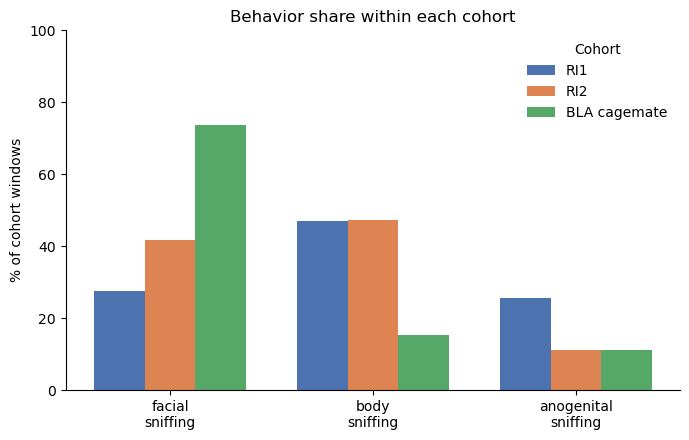

Total interaction windows per cohort (denominator for %):
PlotCohort
RI1             271
RI2              36
BLA cagemate    514


In [106]:
def assign_plot_cohort(df):
    """Split interaction rows into RI1, RI2, and BLA cagemate groups."""
    inter = df[df["Type"] == "Interaction"].copy()

    def _label(row):
        if str(row["Trial"]).startswith("BLA") or str(row["Condition"]).startswith("BLA"):
            return "BLA cagemate"
        if row["Condition"] == "RI1":
            return "RI1"
        if row["Condition"] == "RI2":
            return "RI2"
        return str(row["Condition"])

    inter["PlotCohort"] = inter.apply(_label, axis=1)
    return inter


BEHAVIOR_ORDER = ["facial sniffing", "body sniffing", "anogenital sniffing"]
COHORT_ORDER = ["RI1", "RI2", "BLA cagemate"]
COHORT_COLORS = {"RI1": "#4C72B0", "RI2": "#DD8452", "BLA cagemate": "#55A868"}

plot_df = assign_plot_cohort(master_df_5s)
beh_cohort = (
    plot_df.groupby(["PlotCohort", "Behavior"], observed=True)
    .size()
    .reset_index(name="count")
)
beh_cohort["Behavior"] = pd.Categorical(beh_cohort["Behavior"], categories=BEHAVIOR_ORDER, ordered=True)
beh_cohort["PlotCohort"] = pd.Categorical(beh_cohort["PlotCohort"], categories=COHORT_ORDER, ordered=True)
beh_cohort = beh_cohort.sort_values(["PlotCohort", "Behavior"])

# Count and within-cohort percentage tables
beh_pivot = beh_cohort.pivot(index="Behavior", columns="PlotCohort", values="count").fillna(0).astype(int)
beh_pct = beh_pivot.div(beh_pivot.sum(axis=0), axis=1) * 100

print("Counts:")
display(beh_pivot)
print("Percent within each cohort (%):")
display(beh_pct.round(1))

fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(BEHAVIOR_ORDER))
width = 0.25
for i, cohort in enumerate(COHORT_ORDER):
    pcts = [
        beh_pct.loc[beh, cohort] if beh in beh_pct.index and cohort in beh_pct.columns else 0
        for beh in BEHAVIOR_ORDER
    ]
    ax.bar(x + (i - 1) * width, pcts, width, label=cohort, color=COHORT_COLORS[cohort])
ax.set_xticks(x)
ax.set_xticklabels([b.replace(" ", "\n") for b in BEHAVIOR_ORDER])
ax.set_ylabel("% of cohort windows")
ax.set_ylim(0, 100)
ax.set_title("Behavior share within each cohort")
ax.legend(title="Cohort", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

cohort_totals = plot_df["PlotCohort"].value_counts().reindex(COHORT_ORDER)
print("Total interaction windows per cohort (denominator for %):")
print(cohort_totals.to_string())